In [1]:
from luminis_mc import ResultsLoader
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
})

In [2]:
import os

def max_theta_cbs(anisotropy) -> float:
    wavelength = 0.532
    mean_free_path = 1
    in_radians = wavelength * (1 - anisotropy) / (np.sqrt(2) * mean_free_path)
    return np.degrees(in_radians)

def load_sweep_data(sweep_path: str) -> dict:
    # Validate the input path
    if not sweep_path:
        raise ValueError("The sweep path cannot be empty.")
    
    # Get all the folder names in sweep_path / runs
    runs_path = f"{sweep_path}/runs"
    try:
        run_folders = [f for f in os.listdir(runs_path) if os.path.isdir(os.path.join(runs_path, f))]
    except FileNotFoundError:
        raise FileNotFoundError(f"The specified path '{runs_path}' does not exist.")
    
    data = {}
    for run_folder in run_folders:
        run_path = os.path.join(runs_path, run_folder)
        try:
            loader = ResultsLoader(run_path)
            data[run_folder] = loader
        except Exception as e:
            print(f"Error loading data from {run_path}: {e}")

    return data

In [3]:
path_sweep = '/Users/niaggar/Documents/Thesis/Progress/23Feb26/sim_cbs-linear-res'
sweep_data = load_sweep_data(path_sweep)


# dic_names = {
#     "0000_radius_0.050": {
#         "radius": 0.050,
#         "anisotropy": 0.0659,
#         "max_theta_cbs_deg": max_theta_cbs(0.0659),
#         "max_theta_deg": 25.0,
#     },
#     "0001_radius_0.100": {
#         "radius": 0.100,
#         "anisotropy": 0.2696,
#         "max_theta_cbs_deg": max_theta_cbs(0.2696),
#         "max_theta_deg": 20.0,
#     },
#     "0002_radius_0.200": {
#         "radius": 0.200,
#         "anisotropy": 0.7287,
#         "max_theta_cbs_deg": max_theta_cbs(0.7287),
#         "max_theta_deg": 20.0,
#     },
#     "0003_radius_0.300": {
#         "radius": 0.300,
#         "anisotropy": 0.8437,
#         "max_theta_cbs_deg": max_theta_cbs(0.8437),
#         "max_theta_deg": 15.0,
#     },
#     "0004_radius_0.400": {
#         "radius": 0.400,
#         "anisotropy": 0.8920,
#         "max_theta_cbs_deg": max_theta_cbs(0.8920),
#         "max_theta_deg": 10.0,
#     },
#     "0005_radius_0.500": {
#         "radius": 0.500,
#         "anisotropy": 0.9145,
#         "max_theta_cbs_deg": max_theta_cbs(0.9145),
#         "max_theta_deg": 10.0,
#     },
#     "0006_radius_0.800": {
#         "radius": 0.800,
#         "anisotropy": 0.9301,
#         "max_theta_cbs_deg": max_theta_cbs(0.9301),
#         "max_theta_deg": 10.0,
#     },
#     "0007_radius_1.000": {
#         "radius": 1.000,
#         "anisotropy": 0.9191,
#         "max_theta_cbs_deg": max_theta_cbs(0.9191),
#         "max_theta_deg": 10.0,
#     },
# }

dic_names = {
    "0000_radius_0.050": {
        "radius": 0.050,
        "anisotropy": 0.0659,
        "max_theta_cbs_deg": max_theta_cbs(0.0659),
        "max_theta_deg": 25.0,
    },
    "0001_radius_0.300": {
        "radius": 0.300,
        "anisotropy": 0.8437,
        "max_theta_cbs_deg": max_theta_cbs(0.8437),
        "max_theta_deg": 15.0,
    },
    "0002_radius_0.500": {
        "radius": 0.500,
        "anisotropy": 0.9145,
        "max_theta_cbs_deg": max_theta_cbs(0.9145),
        "max_theta_deg": 10.0,
    },
    "0003_radius_1.000": {
        "radius": 1.000,
        "anisotropy": 0.9191,
        "max_theta_cbs_deg": max_theta_cbs(0.9191),
        "max_theta_deg": 10.0,
    },
}

In [4]:
def plot_disk(sweep_data, run_key, title="CBS Disk Plot", zoom_theta_deg=0.0):
    data = sweep_data[run_key]

    # ... (Tus extracciones de datos se mantienen igual) ...
    meta_sensor = data.sensor_meta("farfield_cbs")
    S0_coh_data = data.derived("farfield_cbs/S0_coh")
    S1_coh_data = data.derived("farfield_cbs/S1_coh")
    S2_coh_data = data.derived("farfield_cbs/S2_coh")
    S3_coh_data = data.derived("farfield_cbs/S3_coh")
    S0_incoh_data = data.derived("farfield_cbs/S0_inc")
    S1_incoh_data = data.derived("farfield_cbs/S1_inc")
    S2_incoh_data = data.derived("farfield_cbs/S2_inc")
    S3_incoh_data = data.derived("farfield_cbs/S3_inc")
    
    # Asumo que theta_data y phi_data son arreglos 2D (meshgrid). 
    # Si son 1D, requerirán np.meshgrid(phi, theta)
    theta_data = data.derived("farfield_cbs/theta")
    phi_data = data.derived("farfield_cbs/phi")

    Ix_c = (S0_coh_data + S1_coh_data) / 2
    Iy_c = (S0_coh_data - S1_coh_data) / 2
    Ix_i = (S0_incoh_data + S1_incoh_data) / 2
    Iy_i = (S0_incoh_data - S1_incoh_data) / 2

    Ico_c = (S0_coh_data + S3_coh_data) / 2
    Ico_i = (S0_incoh_data + S3_incoh_data) / 2
    Icr_c = (S0_coh_data - S3_coh_data) / 2
    Icr_i = (S0_incoh_data - S3_incoh_data) / 2

    It_c = Ix_c + Iy_c
    It_i = Ix_i + Iy_i

    # ── Configuración de la gráfica ──────────────────────────────────────────
    theta_deg = np.degrees(theta_data)
    
    # Determinar el número de filas basado en si hay zoom
    nrows = 3 if zoom_theta_deg > 0.0 else 2
    
    fig, axes = plt.subplots(nrows, 3, figsize=(14, 4.5 * nrows), subplot_kw={'projection': 'polar'})
    fig.suptitle(title, fontsize=16)

    # Organizar los datos por filas
    # Fila 0: Coherente, Fila 1: Incoherente, Fila 2 (Opcional): Coherente Zoom
    plot_data = [
        (It_c, Ix_c, Iy_c), 
        (It_i, Ix_i, Iy_i)   
    ]
    row_labels = ["Coherente", "Incoherente"]
    
    if nrows == 3:
        plot_data.append((It_c, Ix_c, Iy_c))
        row_labels.append(f"Zoom (Coherente)\n$\\theta \\leq {zoom_theta_deg}^\\circ$")

    col_labels = ["$I_{total}$", "$I_{x}$", "$I_{y}$"]

    for r in range(nrows):
        for c in range(3):
            ax = axes[r, c] if nrows > 1 else axes[c]
            Z = plot_data[r][c]

            # ── Reseteo de escala para el zoom mediante Slicing ─────────────────
            if r == 2:
                # Crear máscara booleana 1D de los ángulos válidos
                valid_idx = theta_deg <= zoom_theta_deg
                
                # Recortar arreglos espacialmente
                theta_plot = theta_deg[valid_idx]
                Z_plot = Z[valid_idx, :]
                # Validar si phi_data es 2D (meshgrid) o 1D para aplicarle el recorte
                phi_plot = phi_data[valid_idx, :] if phi_data.ndim == 2 else phi_data
            else:
                theta_plot = theta_deg
                Z_plot = Z
                phi_plot = phi_data

            # contourf recibe exclusivamente los datos recortados
            cplot = ax.contourf(phi_plot, theta_plot, Z_plot, levels=100, cmap='jet')
            
            # Configurar el colorbar
            cbar = fig.colorbar(cplot, ax=ax, fraction=0.046, pad=0.08)
            cbar.formatter.set_powerlimits((0, 0)) # Fuerza la notación científica x10^n
            cbar.ax.yaxis.set_offset_position('right')
            cbar.update_ticks()

            # Ajustar límites radiales visuales
            if r == 2:
                ax.set_ylim(0, zoom_theta_deg)
            else:
                ax.set_ylim(0, np.max(theta_deg))

            # Limpiar ejes y mallas para que parezca un disco puro
            ax.grid(False)
            ax.set_xticks([]) # Oculta los ángulos acimutales
            ax.set_yticks([]) # Oculta los anillos radiales
            ax.spines['polar'].set_visible(True) # Mantiene el borde circular

            # Etiquetas
            if r == 0:
                ax.set_title(col_labels[c], fontsize=14, pad=15)
            if c == 0:
                ax.text(-0.2, 0.5, row_labels[r], transform=ax.transAxes, 
                        va='center', ha='right', fontsize=14, rotation=90)

    plt.tight_layout()
    plt.show()

In [5]:
def plot_radial_cuts(sweep_data, run_key, title="CBS - Linear Polarization", max_theta_deg=20.0, max_theta_cbs=0.0, phi_cuts=[0.0, 45.0, 90.0]):
    data = sweep_data[run_key]

    # Carga de datos
    S0_coh_data = data.derived("farfield_cbs/S0_coh")
    S1_coh_data = data.derived("farfield_cbs/S1_coh")
    S0_incoh_data = data.derived("farfield_cbs/S0_inc")
    S1_incoh_data = data.derived("farfield_cbs/S1_inc")
    
    theta_data = data.derived("farfield_cbs/theta")
    phi_data = data.derived("farfield_cbs/phi")

    # Estados de polarización (Lineal)
    Ix_c = (S0_coh_data + S1_coh_data) / 2
    Iy_c = (S0_coh_data - S1_coh_data) / 2
    Ix_i = (S0_incoh_data + S1_incoh_data) / 2
    Iy_i = (S0_incoh_data - S1_incoh_data) / 2

    It_c = Ix_c + Iy_c
    It_i = Ix_i + Iy_i

    # Manejo robusto de dimensiones asumiendo Z(theta, phi)
    theta_deg = np.degrees(theta_data) if theta_data.ndim == 1 else np.degrees(theta_data[:, 0])
    phi_rad = phi_data if phi_data.ndim == 1 else phi_data[0, :]

    # Configuración de la figura
    nrows = len(phi_cuts)
    fig, axes = plt.subplots(nrows, 3, figsize=(14, 4.5 * nrows), squeeze=False)
    fig.suptitle(title, fontsize=16)

    col_labels = [r"$I_{total}$", r"$I_x$", r"$I_y$"]

    for row, target_phi_deg in enumerate(phi_cuts):
        target_phi_rad = np.radians(target_phi_deg)
        
        # Encontrar el índice de phi más cercano al ángulo objetivo
        phi_idx = np.argmin(np.abs(phi_rad - target_phi_rad))
        actual_phi_deg = np.degrees(phi_rad[phi_idx])

        # Extraer los cortes 1D a lo largo de theta para el phi seleccionado
        cuts = [
            (It_c[:, phi_idx], It_i[:, phi_idx]),
            (Ix_c[:, phi_idx], Ix_i[:, phi_idx]),
            (Iy_c[:, phi_idx], Iy_i[:, phi_idx])
        ]

        for col, (coh, inc) in enumerate(cuts):
            ax = axes[row, col]
            
            # Calcular el factor de realce (enhancement), ignorando divisiones por cero
            with np.errstate(divide='ignore', invalid='ignore'):
                eta = np.where(inc > 0, coh / inc, np.nan)

            ax.plot(theta_deg, coh, label="Coherent", color="blue")
            ax.plot(theta_deg, inc, label="Incoherent", color="orange")
            ax.set_xlabel(r"$\theta$ (deg)")
            ax.set_ylabel("Intensity")
            
            ax.set_title(f"{col_labels[col]} at $\\phi \\approx {actual_phi_deg:.1f}^\\circ$")
            ax.legend(loc="upper right")

            # Eje secundario para el factor de realce
            ax2 = ax.twinx()
            ax2.plot(theta_deg, eta, "k--", alpha=0.5, label=r"$\eta$")
            ax2.set_ylabel(r"Enhancement $\eta$", color="k")
            ax2.legend(loc="lower right")

            ax.set_xlim(0, max_theta_deg)

            # Ancho esperado del CBS
            if max_theta_cbs > 0:
                ax.axvline(max_theta_cbs, color="r", linestyle=":")

    plt.tight_layout()
    plt.show()

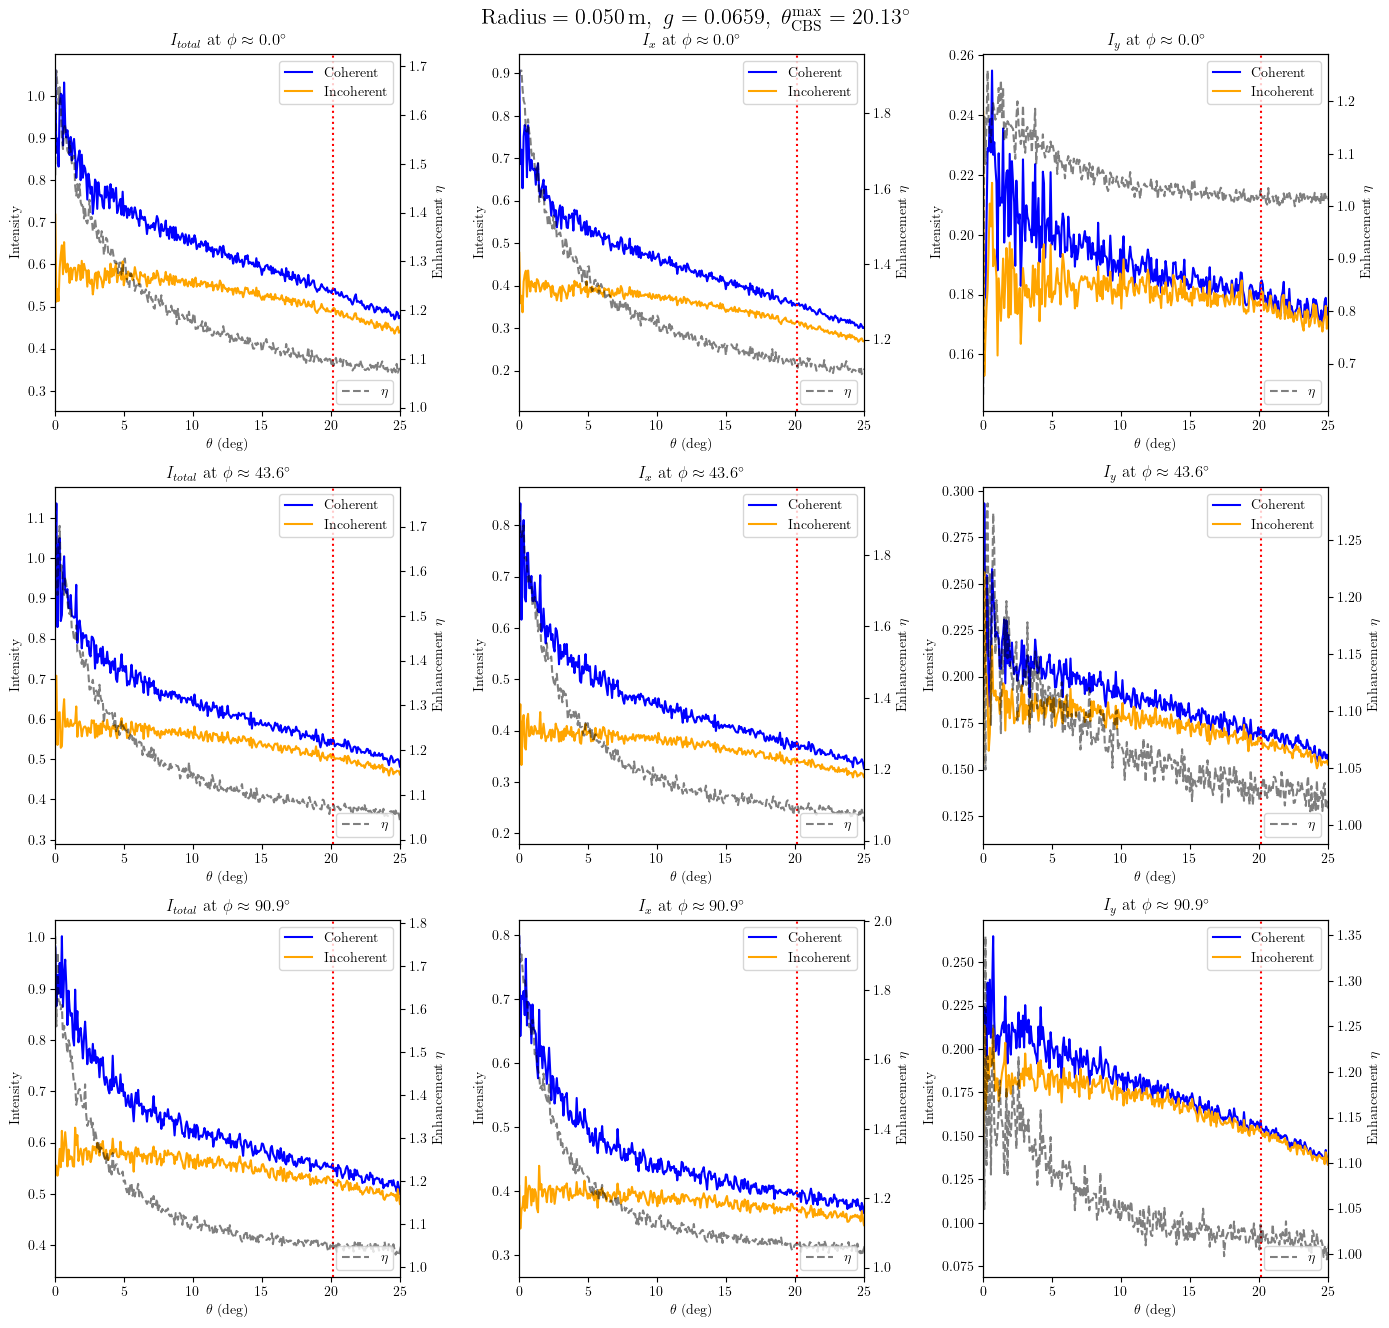

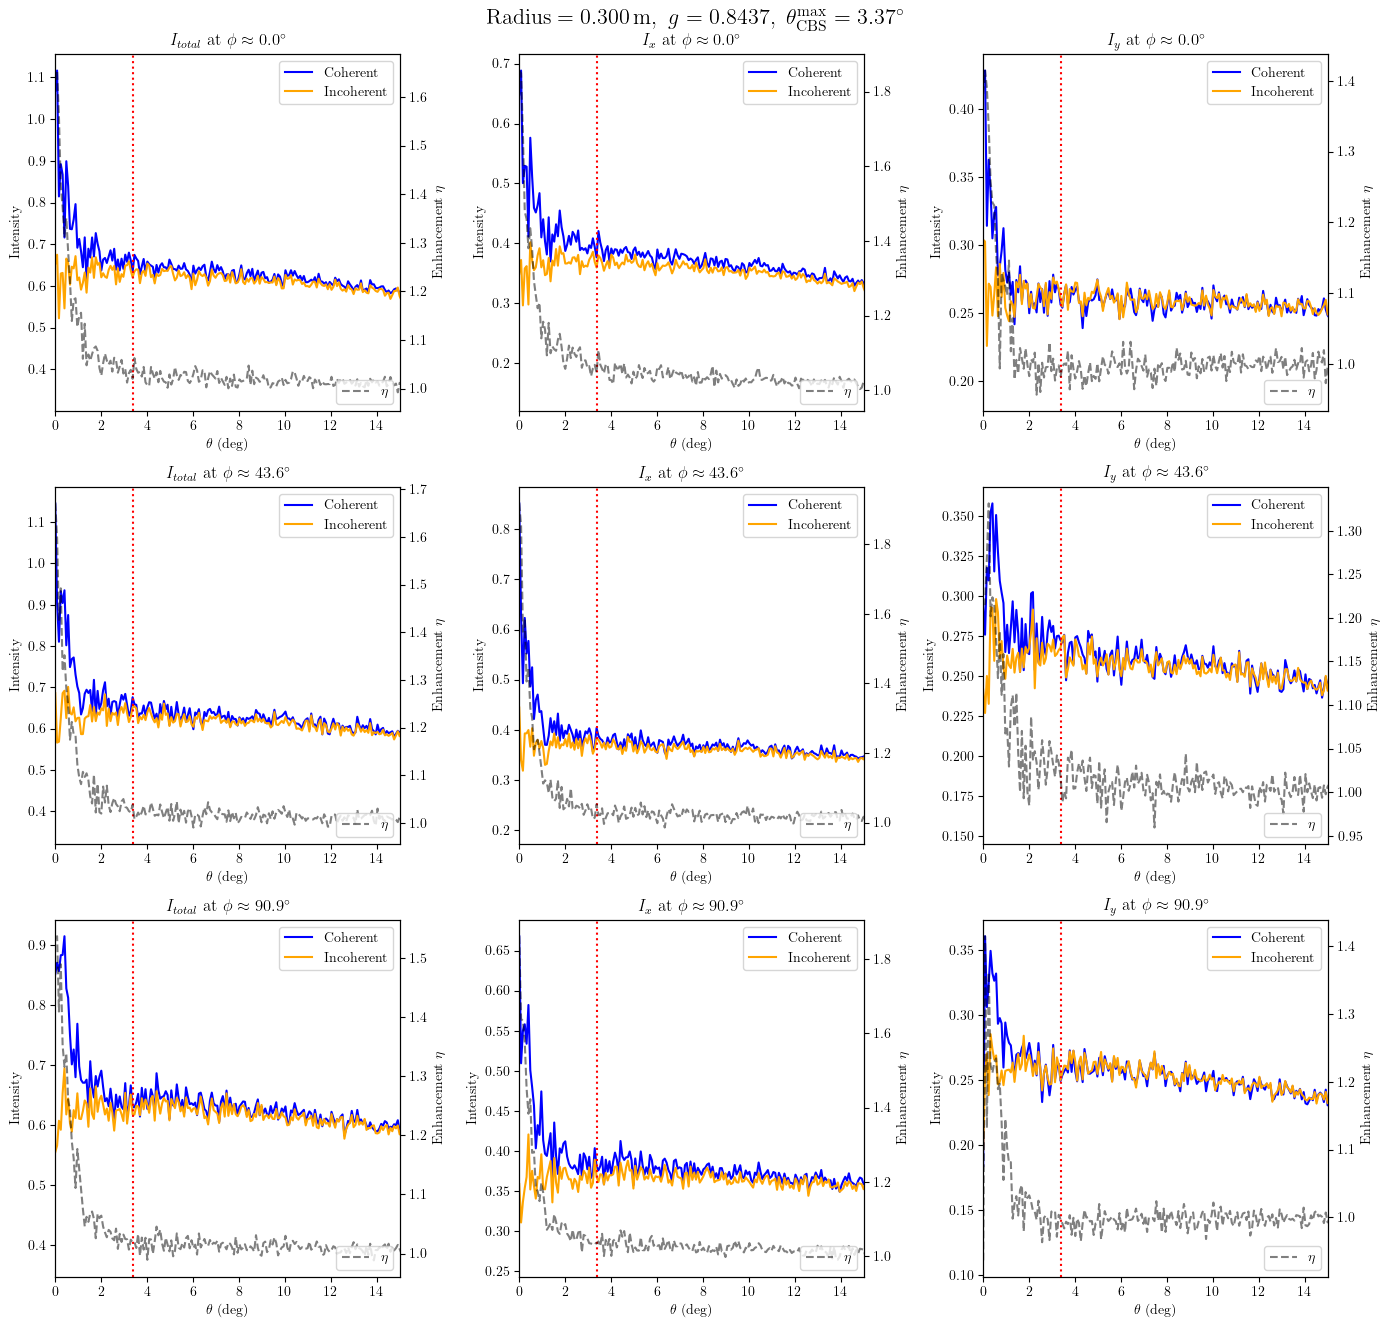

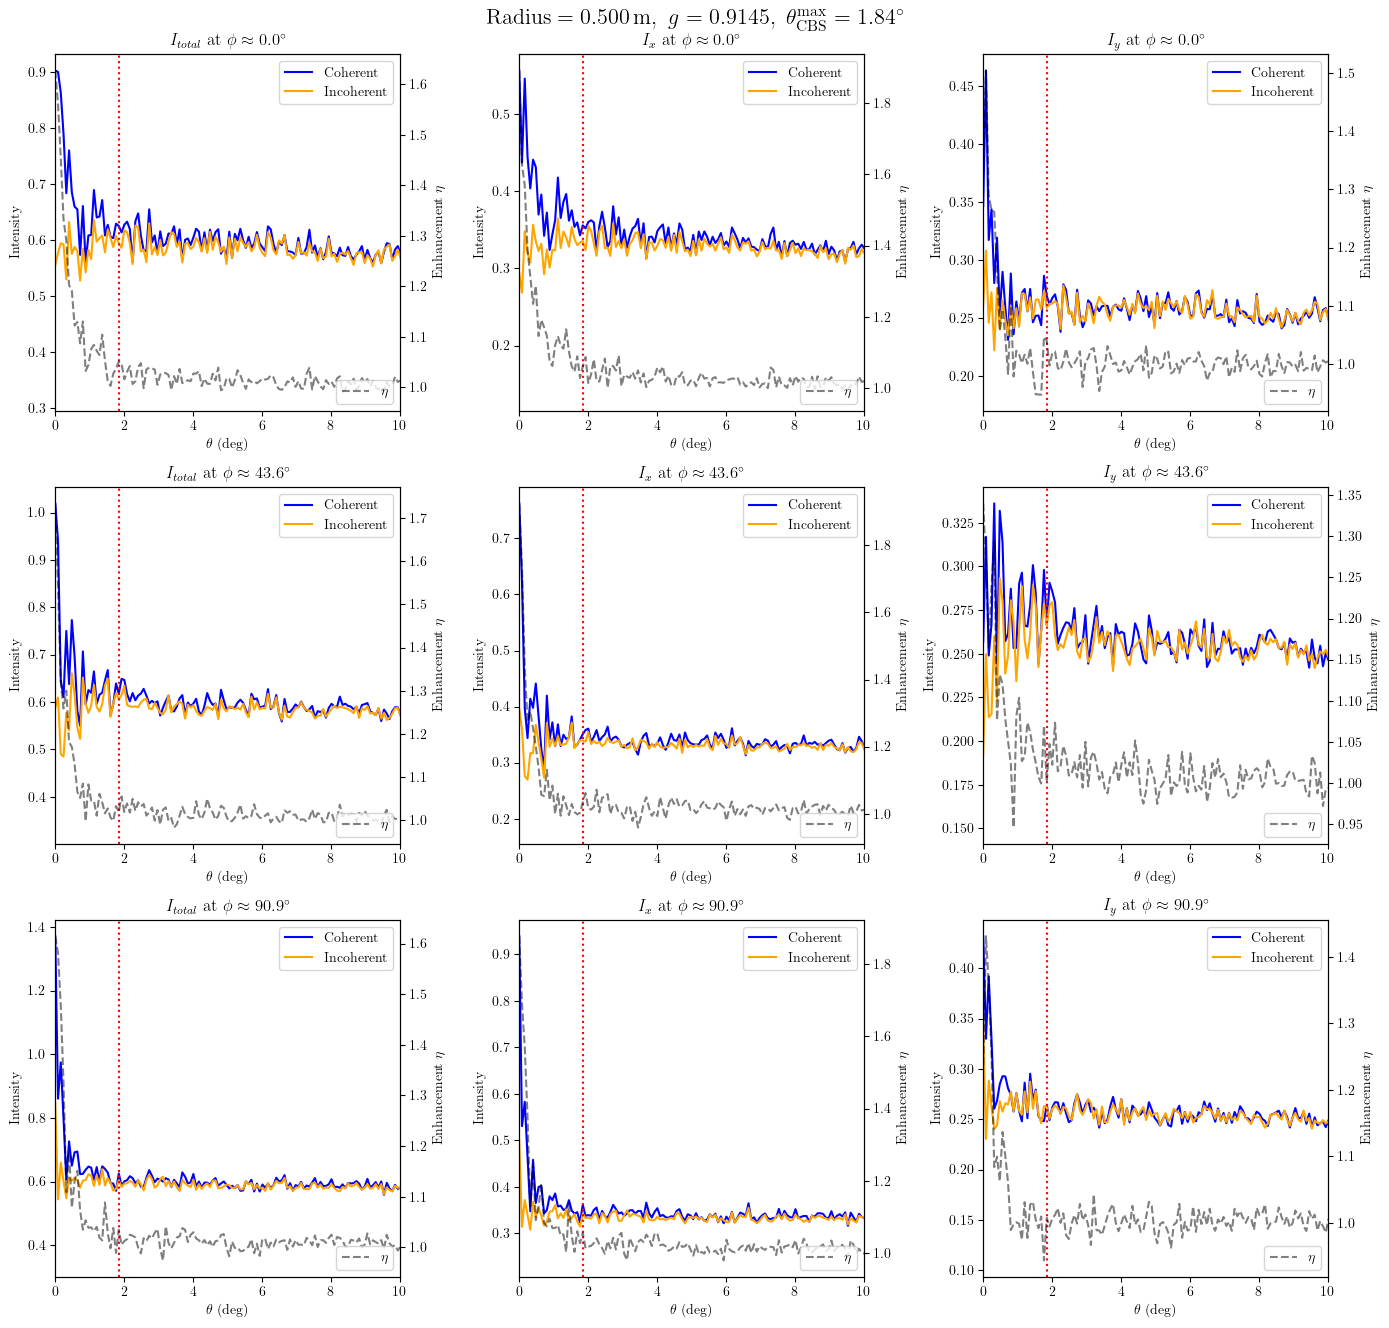

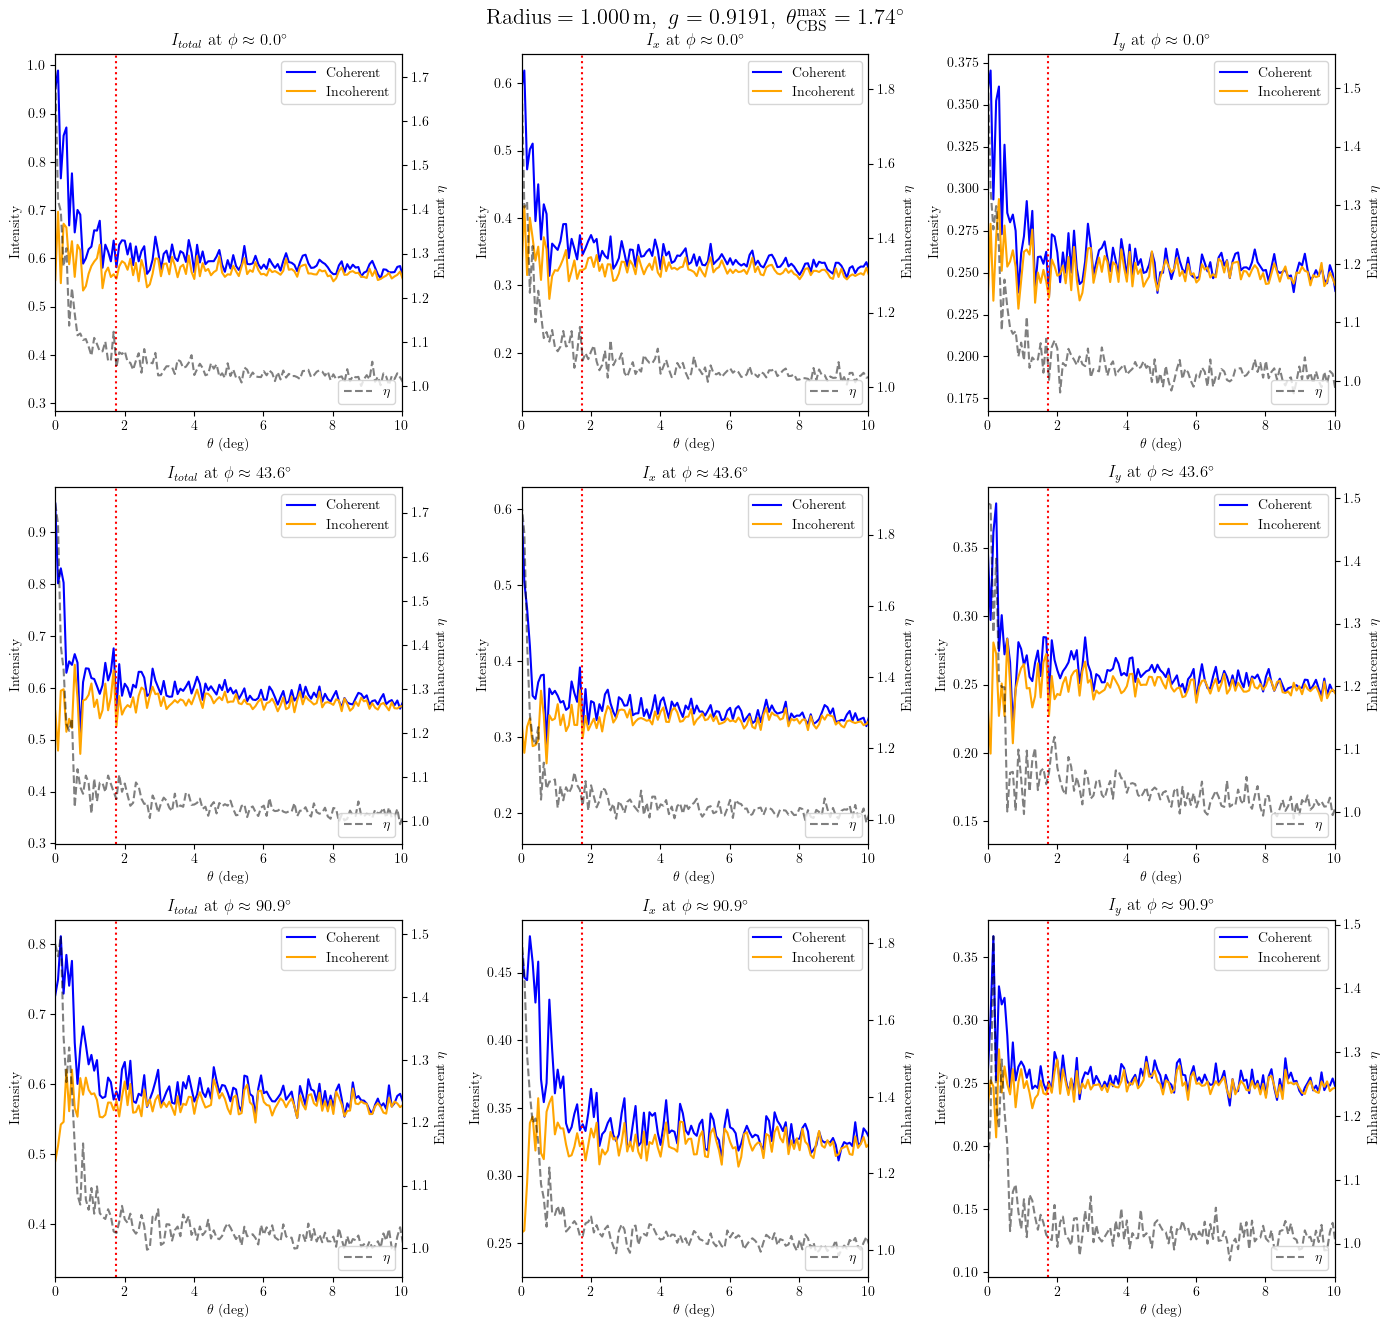

In [6]:
for run_key, info in dic_names.items():
    title = (
        rf"$\mathrm{{Radius}}={info['radius']:.3f}\,"
        rf"\mathrm{{m}},\ g={info['anisotropy']:.4f},\ "
        rf"\theta_{{\mathrm{{CBS}}}}^{{\max}}={info['max_theta_cbs_deg']:.2f}^\circ$"
    )

    mthetacbs = info["max_theta_cbs_deg"]
    mthetadeg = info["max_theta_deg"]
    plot_radial_cuts(sweep_data, run_key, title=title, max_theta_deg=mthetadeg, max_theta_cbs=mthetacbs)


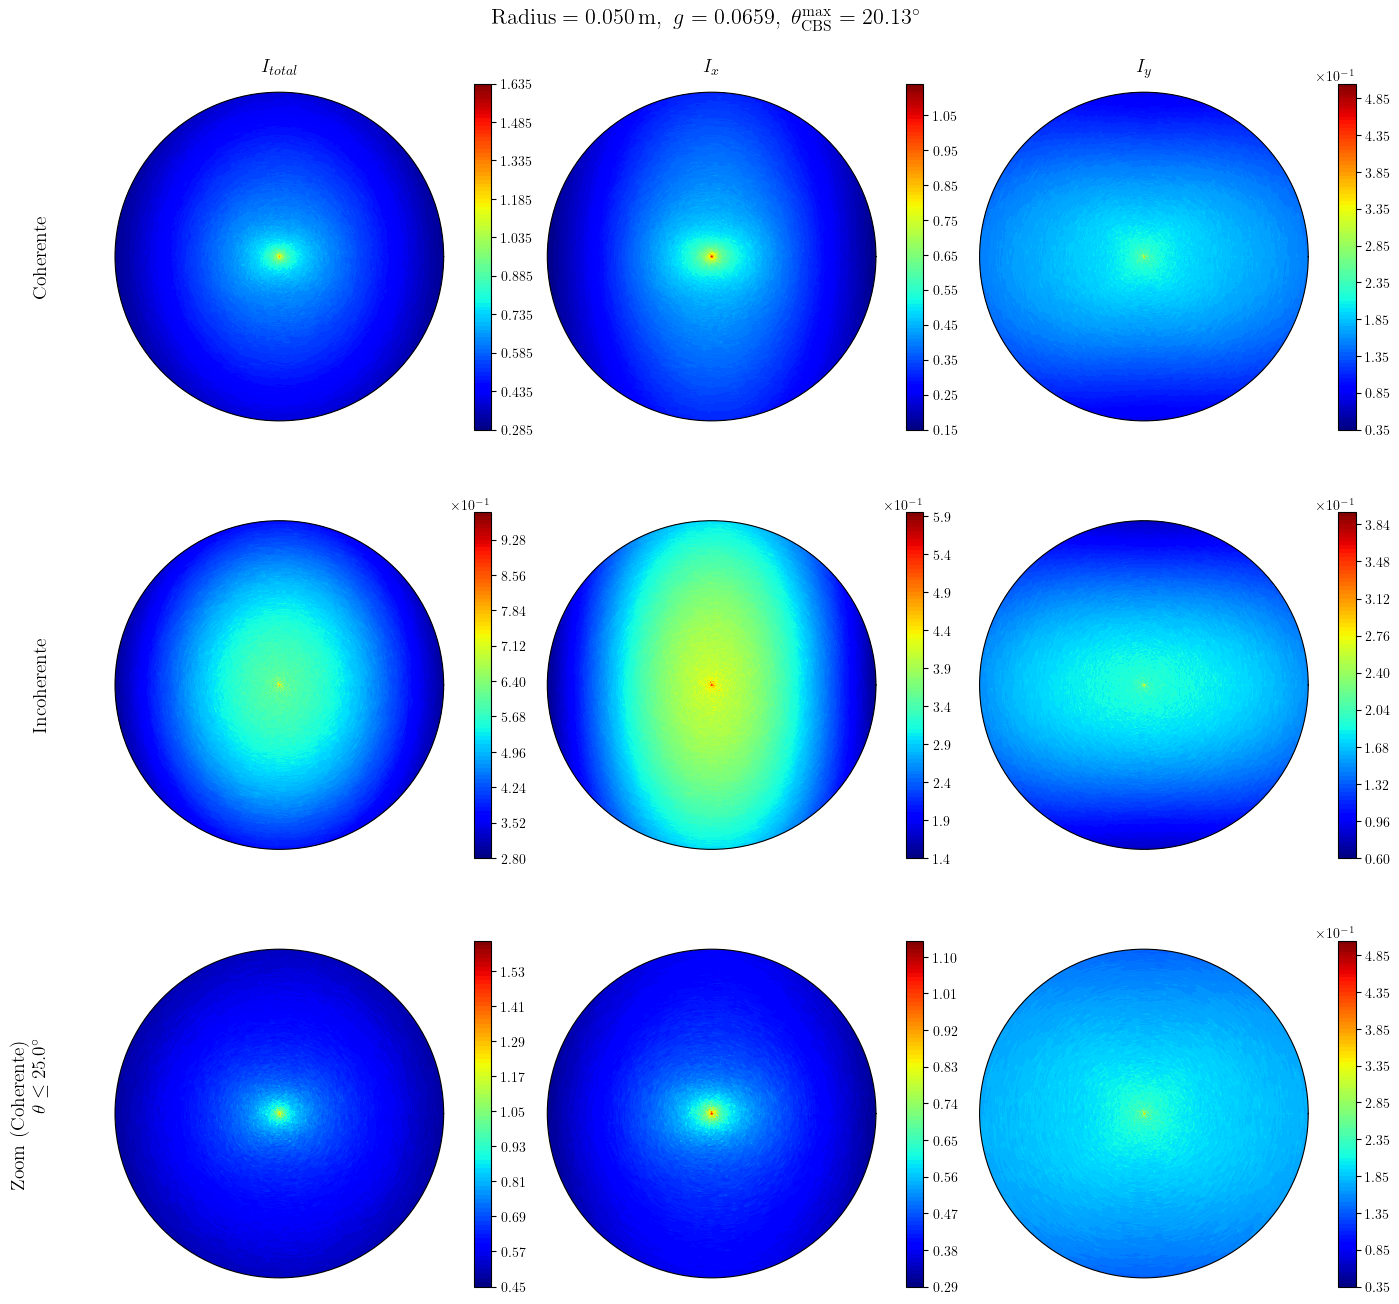

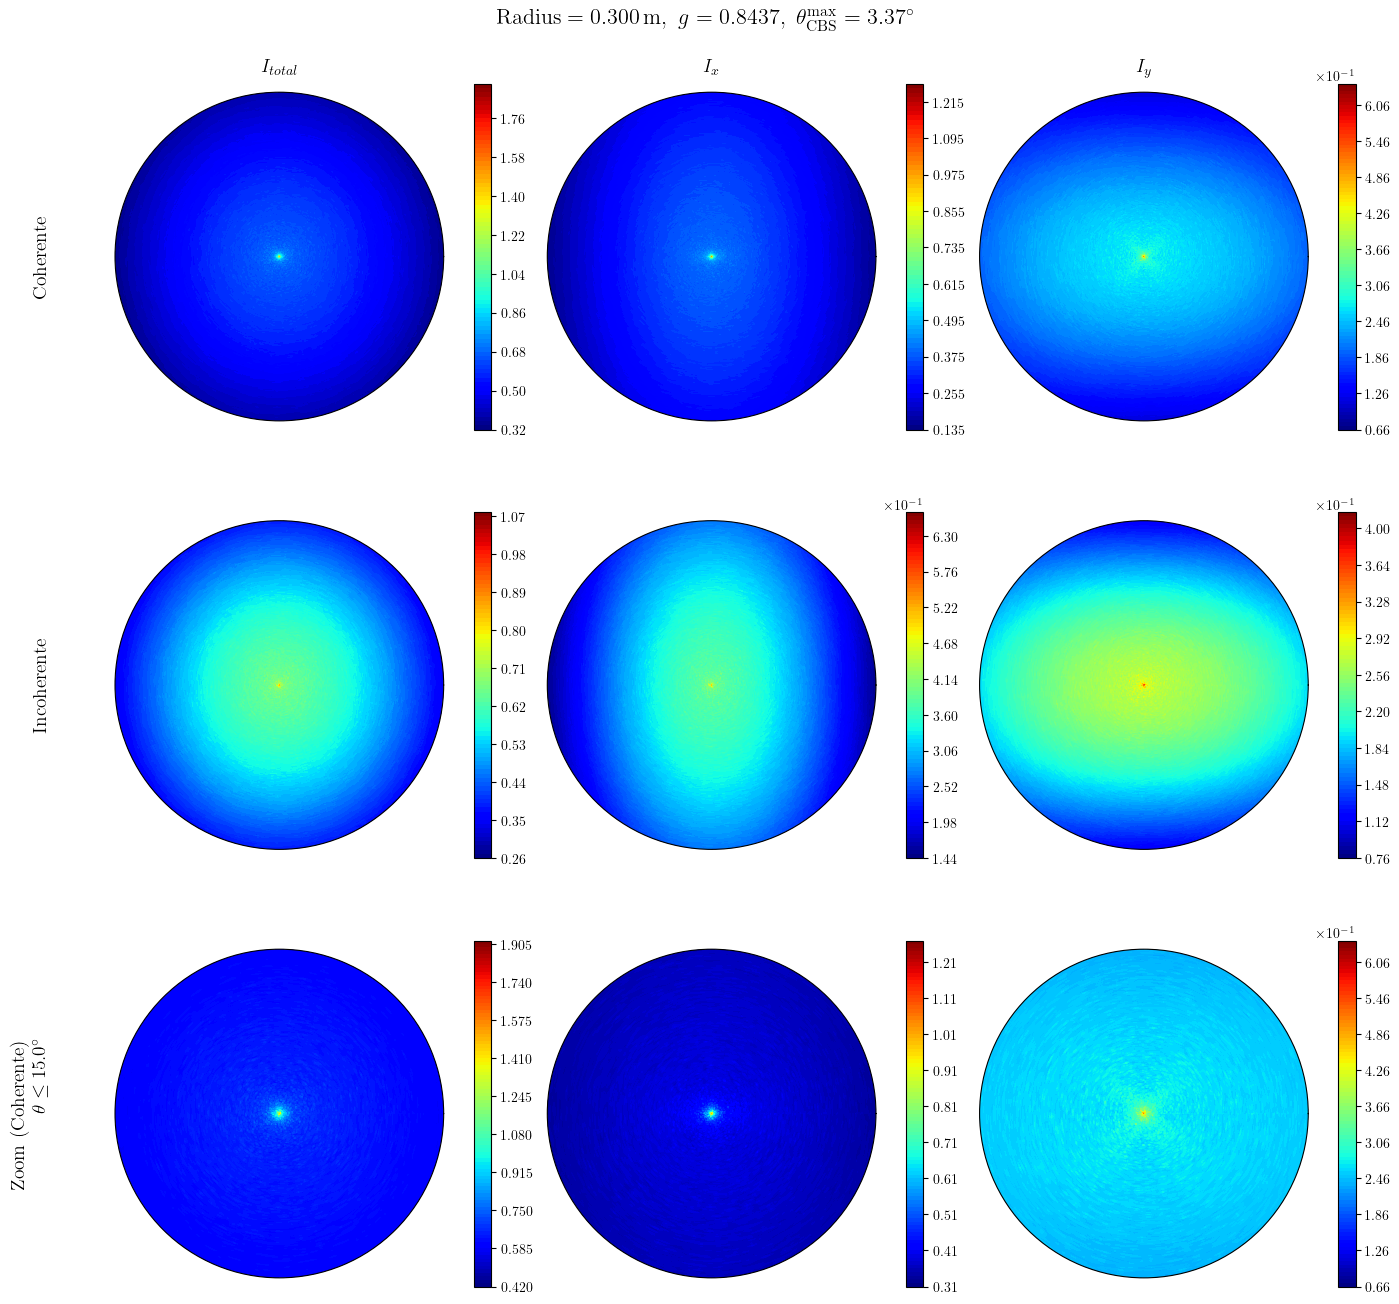

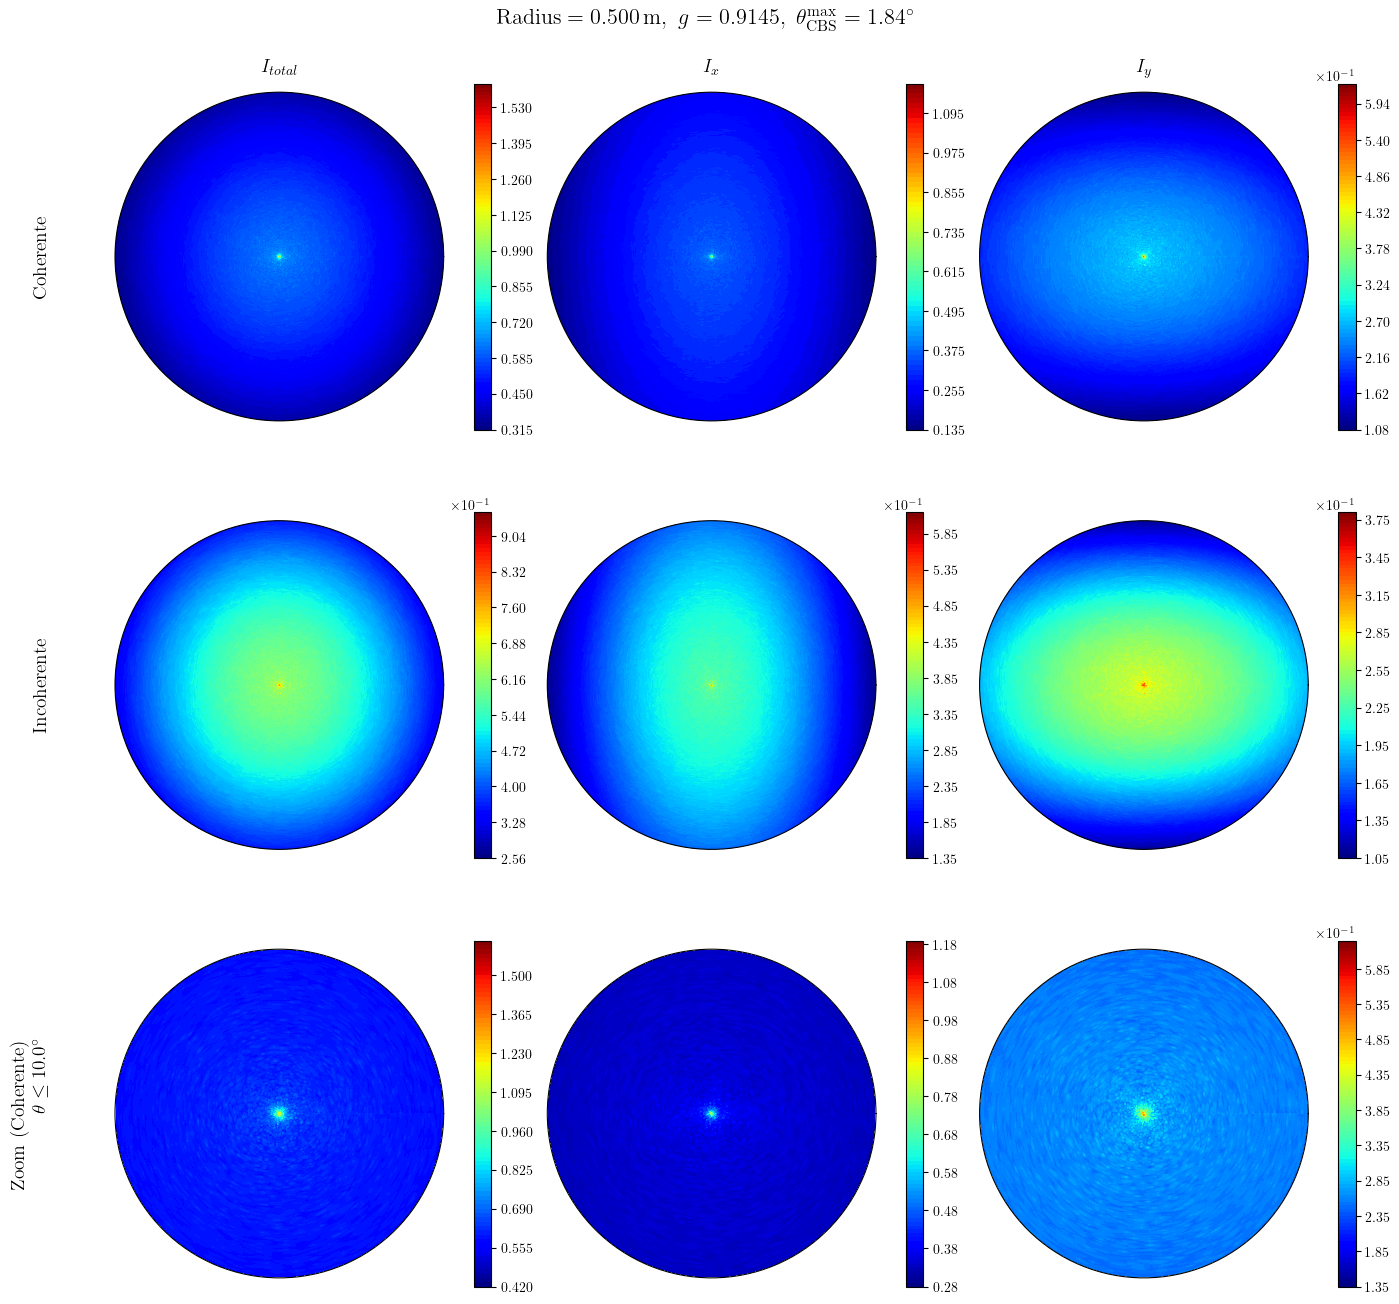

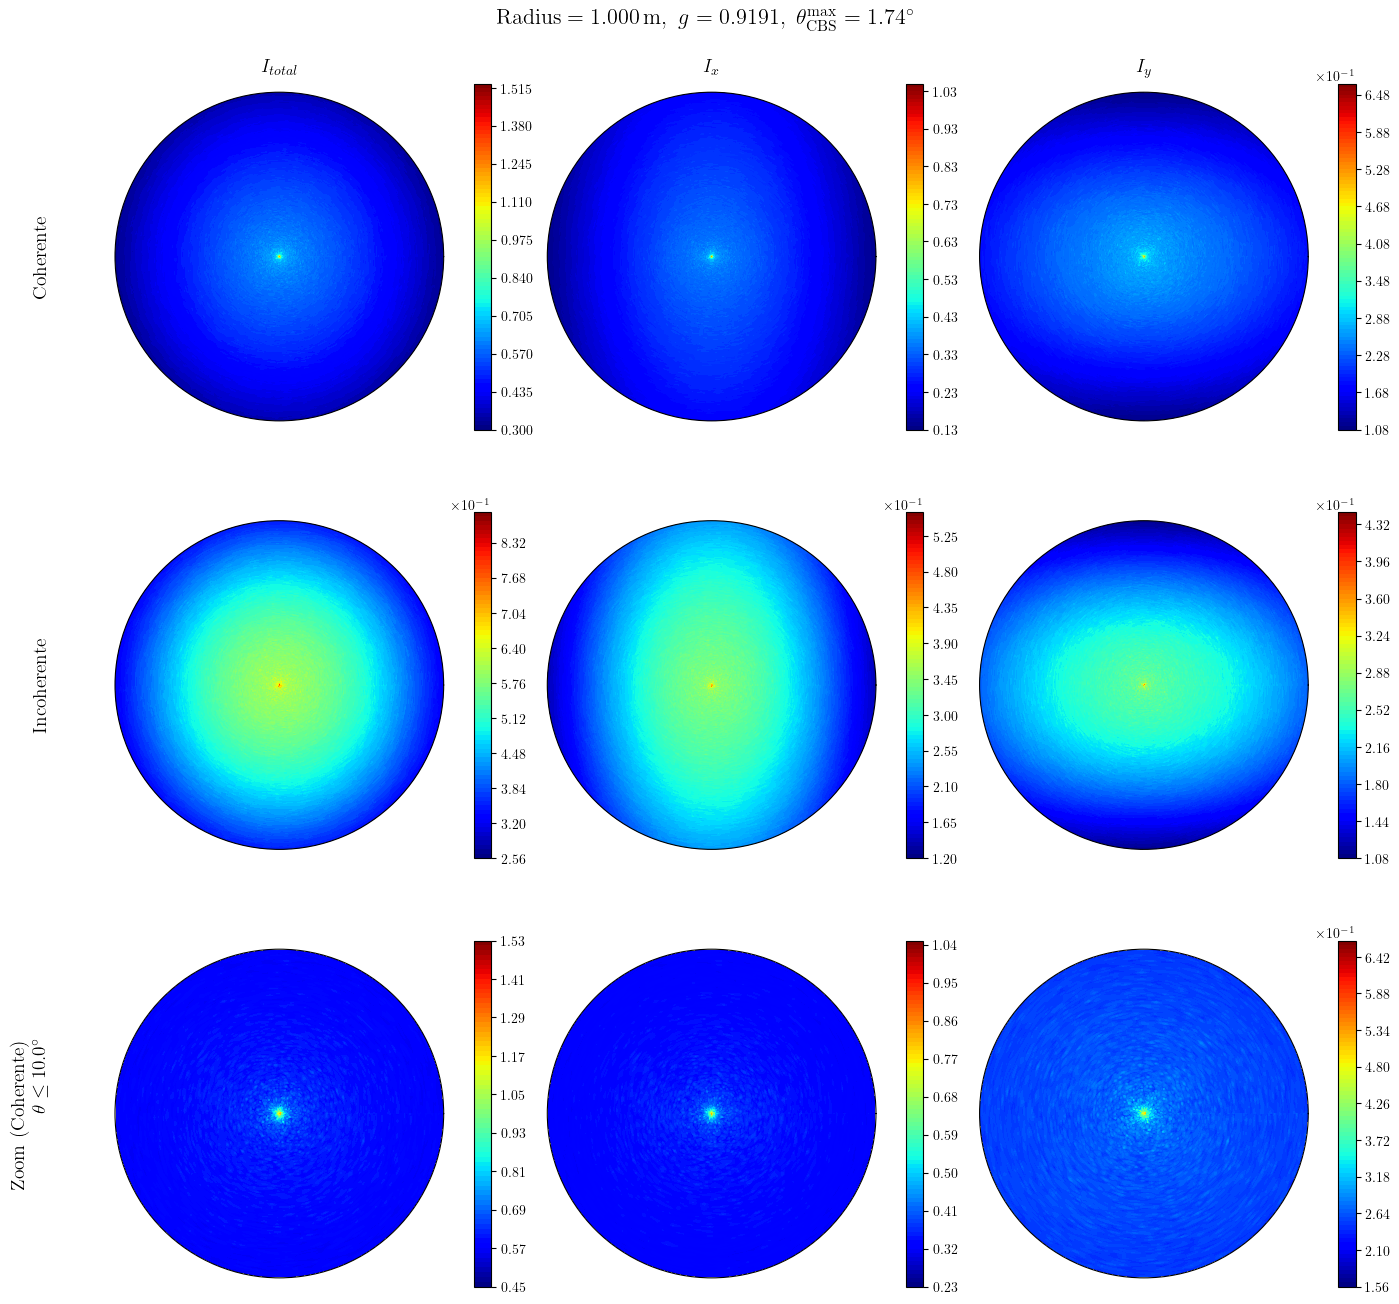

In [7]:
for run_key, info in dic_names.items():
    title = (
        rf"$\mathrm{{Radius}}={info['radius']:.3f}\,"
        rf"\mathrm{{m}},\ g={info['anisotropy']:.4f},\ "
        rf"\theta_{{\mathrm{{CBS}}}}^{{\max}}={info['max_theta_cbs_deg']:.2f}^\circ$"
    )

    mthetacbs = info["max_theta_cbs_deg"]
    zoom_theta_deg = info["max_theta_deg"]
    plot_disk(sweep_data, run_key, title=title, zoom_theta_deg=zoom_theta_deg)